## Pumpkin Pricing

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

- Only get pumpkins priced by the bushel
- Convert the date to a month
- Calculate the price to be an average of high and low prices
- Convert the price to reflect the pricing by bushel quantity

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('../data/US-pumpkins.csv')

pumpkins.head()


,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [3]:
pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

columns_to_select = ['Package', 'Variety', 'City Name', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

month = pd.DatetimeIndex(pumpkins['Date']).month
day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)

new_pumpkins = pd.DataFrame(
    {'Month': month, 
     'DayOfYear' : day_of_year, 
     'Variety': pumpkins['Variety'], 
     'City': pumpkins['City Name'], 
     'Package': pumpkins['Package'], 
     'Low Price': pumpkins['Low Price'],
     'High Price': pumpkins['High Price'], 
     'Price': price})

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/1.1
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price*2

new_pumpkins.head()


C:\Users\Louis Siret\AppData\Local\Temp\ipykernel_22800\2637987050.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  day_of_year = pd.to_datetime(pumpkins['Date']).apply(lambda dt: (dt-datetime(dt.year,1,1)).days)


,Month,DayOfYear,Variety,City,Package,Low Price,High Price,Price
70,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364
71,9,267,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
72,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,18.0,18.0,16.363636
73,10,274,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,17.0,17.0,15.454545
74,10,281,PIE TYPE,BALTIMORE,1 1/9 bushel cartons,15.0,15.0,13.636364


A basic scatterplot reminds us that we only have month data from August through December. We probably need more data to be able to draw conclusions in a linear fashion.

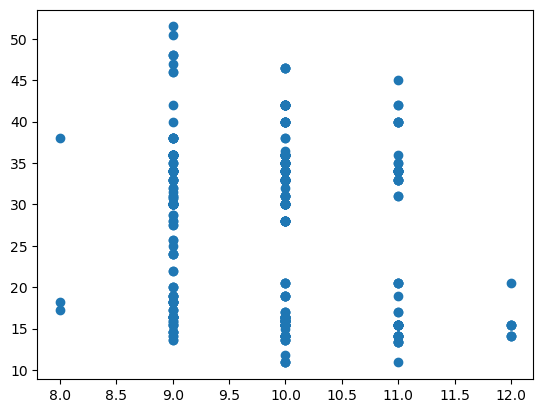

In [4]:
import matplotlib.pyplot as plt
plt.scatter('Month','Price',data=new_pumpkins)

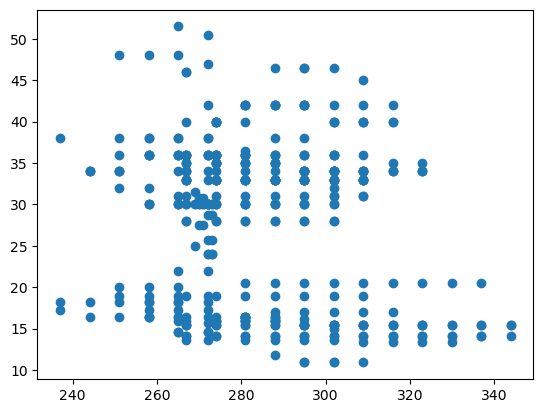

In [5]:

plt.scatter('DayOfYear','Price',data=new_pumpkins)

### Finding Correlations

In [6]:
# Print the correlation between month and price
print(new_pumpkins['Month'].corr(new_pumpkins['Price']))

# Print the correlation between day of year and price
print(new_pumpkins['DayOfYear'].corr(new_pumpkins['Price']))

-0.14878293554077535
-0.16673322492745407


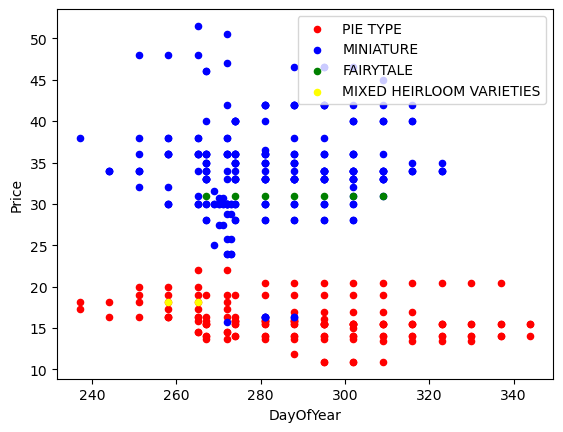

In [7]:
# Colour scatter plot by variety to see clusters

# Define colors for each variety
colors = ['red','blue','green','yellow']

# Plot day of year vs price for each variety
ax=None
for i,var in enumerate(new_pumpkins['Variety'].unique()):
    df = new_pumpkins[new_pumpkins['Variety'] == var]
    ax = df.plot.scatter('DayOfYear', 'Price', ax=ax, c=colors[i], label=var)

In [8]:
# Correlation for specific variety
pie_pumpkins = new_pumpkins[new_pumpkins['Variety']=='PIE TYPE']

print(pie_pumpkins['Month'].corr(pie_pumpkins['Price']))
print(pie_pumpkins['DayOfYear'].corr(pie_pumpkins['Price']))

-0.23841413206125747
-0.2669192282197318


### Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [10]:
X = pie_pumpkins[['DayOfYear']]
y = pie_pumpkins['Price']

X.shape

(144, 1)

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create linear regression model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

LinearRegression()

In [13]:
# Test the model
y_pred = lin_reg.predict(X_test)

print(y_pred)

[16.06447521 16.62792981 14.86407193 16.06447521 16.40744757 15.89298902
 16.45644362 15.89298902 15.89298902 16.62792981 16.45644362 15.2070443
 16.45644362 16.06447521 15.55001666 15.89298902 16.57893375 15.72150284
 15.89298902 15.37853048 15.89298902 15.72150284 15.89298902 16.62792981
 16.40744757 15.37853048 16.06447521 16.23596139 15.03555811]


In [14]:
# Calculate and print the mean error
mse = np.sqrt(mean_squared_error(y_test, y_pred))

# Print the mean squared error in a readable format
print(f'Mean Error: {mse:.2f} ({mse / np.mean(y_pred) * 100:.2f}%)')

Mean Error: 2.34 (14.65%)


In [15]:
# Get the coefficient of determination

r2 = lin_reg.score(X_test, y_test)
print(f'R^2: {r2 * 100:.2f}%')

R^2: 4.04%


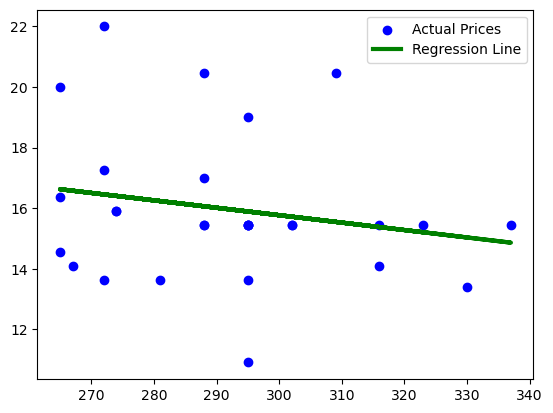

In [16]:
# Plot the regression line against the test data
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='green', linewidth=3, label='Regression Line')
plt.legend()

### Polynomial Regression

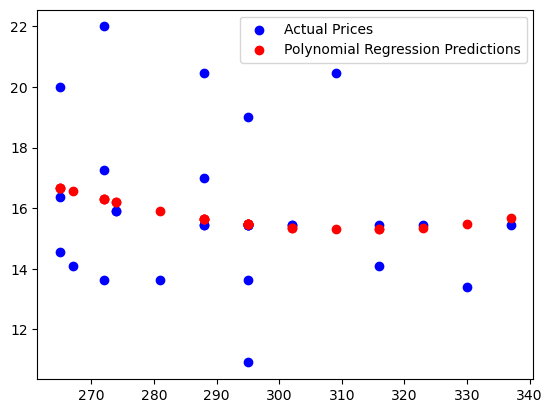

In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define polynomial regression model
pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())

# Train the polynomial regression model
pipeline.fit(X_train, y_train)

# Test the polynomial regression model
pred = pipeline.predict(X_test)

# Plot the polynomial regression line against the test data
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.scatter(X_test, pred, color='red', label='Polynomial Regression Predictions')
plt.legend()

In [ ]:
# Calculate the mean error
mse = np.sqrt(mean_squared_error(y_test, pred))

# Print the mean squared error in a readable format
print(f'Mean Error: {mse:.2f} ({mse / np.mean(pred) * 100:.2f}%)')

Mean Error: 2.36 (14.95%)


In [19]:
# Calculate the score of the polynomial regression model
r2_poly = pipeline.score(X_test, y_test)

print(f'R^2 (Polynomial): {r2_poly * 100:.2f}%')

R^2 (Polynomial): 2.29%


### Categorising

In [24]:
X = pd.get_dummies(new_pumpkins['Variety']).join(new_pumpkins['Month']).join(pd.get_dummies(new_pumpkins['City'])).join(pd.get_dummies(new_pumpkins['Package']))

y = new_pumpkins['Price']

In [31]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create linear regression model
lin_reg = LinearRegression()

# Train the model
lin_reg.fit(X_train, y_train)

# Test the model
pred = lin_reg.predict(X_test)

# Calculate and print the mean error
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean Error: {mse:.2f} ({mse / np.mean(pred) * 100:.2f}%)')

# Calculate the Determination of the model
score = lin_reg.score(X_test, y_test)
print(f'Determination: {score * 100:.2f}%')

Mean Error: 2.84 (10.54%)
Determination: 93.06%


In [32]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create linear regression model
poly_reg = make_pipeline(PolynomialFeatures(2), LinearRegression())

# Train the model
poly_reg.fit(X_train, y_train)

# Test the model
pred = poly_reg.predict(X_test)

# Calculate and print the mean error
mse = np.sqrt(mean_squared_error(y_test, pred))
print(f'Mean Error: {mse:.2f} ({mse / np.mean(pred) * 100:.2f}%)')

# Calculate the Determination of the model
score = poly_reg.score(X_test, y_test)
print(f'Determination: {score * 100:.2f}%')

Mean Error: 2.22 (8.23%)
Determination: 95.75%
